# **Crop_production Analysis**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Data collection
data = pd.read_csv('crop_production.csv')
data.head()

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


In [ ]:
# Data preprocessing

# a.Handling Missing Values
print(data.isnull().sum())

State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64


In [ ]:
# b. Data Type Conversion
data['Area'] = data['Area'].astype(float)
data['Production'] = data['Production'].astype(float)
# Convert 'Crop_Year' to categorical if it's not
data['Crop_Year'] = data['Crop_Year'].astype('category')

In [ ]:
# c. Encoding Categorical Variables
data = pd.get_dummies(data, columns=['Season', 'Crop'], drop_first=True)


In [ ]:
# 3. Feature Engineering
data['Yield'] = data['Production'] / data['Area']


In [ ]:
# 4. Model Selection
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X = data.drop(['Production'], axis=1)
y = data['Production']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestRegressor()


In [ ]:
model.fit(X_train, y_train)


ValueError: could not convert string to float: 'Odisha'

Mean Squared Error: 311324198300562.25, R^2 Score: 0.22621191775779625
Crop_Coconut                    4.537612e+07
District_Name_KOZHIKODE         3.060789e+07
State_Name_Kerala               1.995067e+07
District_Name_THRISSUR          1.838422e+07
District_Name_MALAPPURAM        1.370168e+07
                                    ...     
District_Name_FAZILKA          -1.450747e+07
District_Name_PATHANAMTHITTA   -1.464893e+07
District_Name_IDUKKI           -1.690141e+07
District_Name_WAYANAD          -1.866638e+07
Crop_Rubber                    -1.989666e+07
Length: 812, dtype: float64


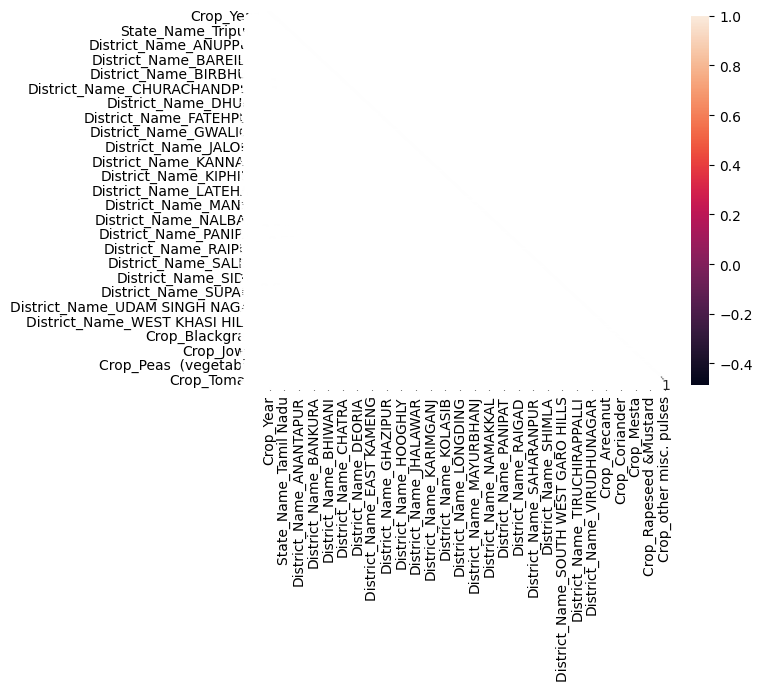

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load Dataset
data = pd.read_csv("crop_production.csv")

# Step 2: Data Preprocessing
data.dropna(inplace=True)  # Handle missing values

# Convert categorical features
data = pd.get_dummies(data, columns=['State_Name', 'District_Name', 'Season', 'Crop'])

# Step 3: Feature Engineering
data['Yield'] = data['Production'] / data['Area']

# Step 4: Model Selection
X = data.drop(columns=['Production'])
y = data['Production']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Model Training
model = LinearRegression()
model.fit(X_train, y_train)

# Step 6: Model Evaluation
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}, R^2 Score: {r2}")

# Step 7: Interpretation and Insights
feature_importance = pd.Series(model.coef_, index=X_train.columns)
print(feature_importance.sort_values(ascending=False))

# Step 8: Visualization
sns.heatmap(data.corr(), annot=True)
plt.show()

# Step 9: Comparison and Useful Information Extraction
# Further visualizations can be created here


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer  # Import SimpleImputer
import numpy as np # Import numpy for np.nan

# Load the dataset
data = pd.read_csv('crop_production.csv')

# Clean column names
data.columns = data.columns.str.strip()

# Check for missing values and handle them if necessary
print(data.isnull().sum())

# Convert data types
data['Area'] = data['Area'].astype(float)
data['Production'] = data['Production'].astype(float)
data['Crop_Year'] = data['Crop_Year'].astype('category')

# Create a new feature: Yield
# Handle potential division by zero
data['Yield'] = data['Production'] / data['Area'].replace(0, np.nan)

# One-hot encode categorical variables
categorical_columns = data.select_dtypes(include=['object']).columns
data = pd.get_dummies(data, columns=categorical_columns, drop_first=True)

# *** Impute missing values in 'Production' (y) as well ***
# Impute missing values using the mean
imputer = SimpleImputer(strategy='mean')  # Create an imputer object
X = data.drop(['Production'], axis=1)
y = data['Production']

# Fit and transform on X and y separately to avoid data leakage
X = imputer.fit_transform(X) # Fit and transform the data for features
y = imputer.fit_transform(y.values.reshape(-1, 1)) # Fit and transform the target variable
y = y.ravel() # Convert back to 1D array

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Initialize and train the model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Make predictions
y_pred_linear = linear_model.predict(X_test)

# Evaluate the model
print("Linear Regression:")
print(f'MAE: {mean_absolute_error(y_test, y_pred_linear)}')
print(f'RMSE: {mean_squared_error(y_test, y_pred_linear, squared=False)}')
print(f'R²: {r2_score(y_test, y_pred_linear)}\n')

State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64
Linear Regression:
MAE: 1831843.4455496578
RMSE: 12271208.580113644
R²: 0.056290150398629835



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor  # Import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor  # Import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer  # Import SimpleImputer
import numpy as np # Import numpy for np.nan

# Load the dataset
data = pd.read_csv('crop_production.csv')

# Clean column names
data.columns = data.columns.str.strip()

# Check for missing values and handle them if necessary
print(data.isnull().sum())

# Convert data types
data['Area'] = data['Area'].astype(float)
data['Production'] = data['Production'].astype(float)
data['Crop_Year'] = data['Crop_Year'].astype('category')

# Create a new feature: Yield
# Handle potential division by zero
data['Yield'] = data['Production'] / data['Area'].replace(0, np.nan)

# One-hot encode categorical variables
categorical_columns = data.select_dtypes(include=['object']).columns
data = pd.get_dummies(data, columns=categorical_columns, drop_first=True)

# *** Impute missing values in 'Production' (y) as well ***
# Impute missing values using the mean
imputer = SimpleImputer(strategy='mean')  # Create an imputer object
X = data.drop(['Production'], axis=1)
y = data['Production']

# Fit and transform on X and y separately to avoid data leakage
X = imputer.fit_transform(X) # Fit and transform the data for features
y = imputer.fit_transform(y.values.reshape(-1, 1)) # Fit and transform the target variable
y = y.ravel() # Convert back to 1D array

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Make predictions for Linear Regression
y_pred_linear = linear_model.predict(X_test)

# Evaluate the Linear Regression model
print("Linear Regression:")
print(f'MAE: {mean_absolute_error(y_test, y_pred_linear)}')
print(f'RMSE: {mean_squared_error(y_test, y_pred_linear, squared=False)}')
print(f'R²: {r2_score(y_test, y_pred_linear)}\n')

# Initialize and train the Decision Tree model
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)  # Now X_train and y_train are defined

# Make predictions for Decision Tree
y_pred_tree = tree_model.predict(X_test)

# Evaluate the Decision Tree model
print("Decision Tree:")
print(f'MAE: {mean_absolute_error(y_test, y_pred_tree)}')
print(f'RMSE: {mean_squared_error(y_test, y_pred_tree, squared=False)}')
print(f'R²: {r2_score(y_test, y_pred_tree)}\n')

State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64
Linear Regression:
MAE: 1831843.4455496578
RMSE: 12271208.580113644
R²: 0.056290150398629835



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Decision Tree:
MAE: 31541.16140133404
RMSE: 1583077.4848348815
R²: 0.9842939073105862



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [ ]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
# Import RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer  # Import SimpleImputer
import numpy as np # Import numpy for np.nan

# Load the dataset
data = pd.read_csv('crop_production.csv')

# Clean column names
data.columns = data.columns.str.strip()

# Check for missing values and handle them if necessary
print(data.isnull().sum())

# Convert data types
data['Area'] = data['Area'].astype(float)
data['Production'] = data['Production'].astype(float)
data['Crop_Year'] = data['Crop_Year'].astype('category')

# Create a new feature: Yield
# Handle potential division by zero
data['Yield'] = data['Production'] / data['Area'].replace(0, np.nan)

# One-hot encode categorical variables
categorical_columns = data.select_dtypes(include=['object']).columns
data = pd.get_dummies(data, columns=categorical_columns, drop_first=True)

# *** Impute missing values in 'Production' (y) as well ***
# Impute missing values using the mean
imputer = SimpleImputer(strategy='mean')  # Create an imputer object
X = data.drop(['Production'], axis=1)
y = data['Production']

# Fit and transform on X and y separately to avoid data leakage
X = imputer.fit_transform(X) # Fit and transform the data for features
y = imputer.fit_transform(y.values.reshape(-1, 1)) # Fit and transform the target variable
y = y.ravel() # Convert back to 1D array

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
forest_model = RandomForestRegressor(random_state=42)
forest_model.fit(X_train, y_train) # X_train and y_train are now defined in this cell


# Make predictions
y_pred_forest = forest_model.predict(X_test)

# Evaluate the model
print("Random Forest:")
print(f'MAE: {mean_absolute_error(y_test, y_pred_forest)}')
print(f'RMSE: {mean_squared_error(y_test, y_pred_forest, squared=False)}')
print(f'R²: {r2_score(y_test, y_pred_forest)}\n')

# Feature importance
importances = forest_model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

# Plot feature importances
plt.figure()
plt.title("Feature importances")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), feature_names[indices], rotation=90)
plt.xlim([-1, X.shape[1]])
plt.show()

State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
data = pd.read_csv('crop_production.csv')

# Clean column names
data.columns = data.columns.str.strip()

# Check for missing values
print(data.isnull().sum())

# Convert data types
data['Area'] = data['Area'].astype(float)
data['Production'] = data['Production'].astype(float)
data['Crop_Year'] = data['Crop_Year'].astype('category')

# Create a new feature: Yield
# Handle potential division by zero
data['Yield'] = data['Production'] / data['Area'].replace(0, np.nan)

# One-hot encode categorical variables
categorical_columns = data.select_dtypes(include=['object']).columns
data = pd.get_dummies(data, columns=categorical_columns, drop_first=True)

# *** Impute missing values in 'Production' (y) as well ***
# Impute missing values using the mean
imputer = SimpleImputer(strategy='mean')  # Create an imputer object
X = data.drop(['Production'], axis=1)
y = data['Production']

# Fit and transform on X and y separately to avoid data leakage
X = imputer.fit_transform(X)  # Fit and transform the data for features
y = imputer.fit_transform(y.values.reshape(-1, 1))  # Fit and transform the target variable
y = y.ravel()  # Convert back to 1D array

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 1: Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 2: Cross-Validation and Model Training
# Initialize models
linear_model = LinearRegression()
tree_model = DecisionTreeRegressor(random_state=42)
forest_model = RandomForestRegressor(random_state=42)

# Cross-Validation with R² score
for model, model_name in zip([linear_model, tree_model, forest_model],
                             ['Linear Regression', 'Decision Tree', 'Random Forest']):
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    print(f"{model_name} Cross-Validation R²: {np.mean(scores):.4f} ± {np.std(scores):.4f}")

# Step 3: Hyperparameter Tuning for Random Forest
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10]
}
grid_search = GridSearchCV(forest_model, param_grid, cv=5, scoring='r2')
grid_search.fit(X_train_scaled, y_train)

# Best model parameters
best_forest_model = grid_search.best_estimator_
print(f"Best Parameters for Random Forest: {grid_search.best_params_}")

# Step 4: Model Training and Evaluation
# Linear Regression
linear_model.fit(X_train_scaled, y_train)
y_pred_linear = linear_model.predict(X_test_scaled)
print("Linear Regression:")
print(f'MAE: {mean_absolute_error(y_test, y_pred_linear)}')
print(f'RMSE: {mean_squared_error(y_test, y_pred_linear, squared=False)}')
print(f'R²: {r2_score(y_test, y_pred_linear)}\n')

# Decision Tree
tree_model.fit(X_train_scaled, y_train)
y_pred_tree = tree_model.predict(X_test_scaled)
print("Decision Tree:")
print(f'MAE: {mean_absolute_error(y_test, y_pred_tree)}')
print(f'RMSE: {mean_squared_error(y_test, y_pred_tree, squared=False)}')
print(f'R²: {r2_score(y_test, y_pred_tree)}\n')

# Random Forest (Tuned)
y_pred_forest = best_forest_model.predict(X_test_scaled)
print("Random Forest (Tuned):")
print(f'MAE: {mean_absolute_error(y_test, y_pred_forest)}')
print(f'RMSE: {mean_squared_error(y_test, y_pred_forest, squared=False)}')
print(f'R²: {r2_score(y_test, y_pred_forest)}\n')

# Step 5: Visualization and Insights
# Feature Importance for Random Forest
feature_importance = best_forest_model.feature_importances_
features = data.drop(['Production'], axis=1).columns

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(features, feature_importance)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()

# Correlation Matrix
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Actual vs Predicted for Random Forest
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_forest)
plt.title("Random Forest: Actual vs Predicted")
plt.xlabel("Actual Production")
plt.ylabel("Predicted Production")
plt.show()


State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64
Linear Regression Cross-Validation R²: -594961810520158091870208.0000 ± 756016749490564730191872.0000
Decision Tree Cross-Validation R²: 0.9812 ± 0.0117
Random Forest Cross-Validation R²: 0.9893 ± 0.0062


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
data = pd.read_csv('crop_production.csv')

In [ ]:
# Clean column names
data.columns = data.columns.str.strip()

# Check for missing values
print(data.isnull().sum())

# Convert data types
data['Area'] = data['Area'].astype(float)
data['Production'] = data['Production'].astype(float)
data['Crop_Year'] = data['Crop_Year'].astype('category')

State_Name         0
District_Name      0
Crop_Year          0
Season             0
Crop               0
Area               0
Production       253
dtype: int64


In [ ]:
# Create a new feature: Yield
# Handle potential division by zero
data['Yield'] = data['Production'] / data['Area'].replace(0, np.nan)

# One-hot encode categorical variables
categorical_columns = data.select_dtypes(include=['object']).columns
data = pd.get_dummies(data, columns=categorical_columns, drop_first=True)

In [ ]:
# *** Impute missing values in 'Production' (y) as well ***
# Impute missing values using the mean
imputer = SimpleImputer(strategy='mean')  # Create an imputer object
X = data.drop(['Production'], axis=1)
y = data['Production']

# Fit and transform on X and y separately to avoid data leakage
X = imputer.fit_transform(X)  # Fit and transform the data for features
y = imputer.fit_transform(y.values.reshape(-1, 1))  # Fit and transform the target variable
y = y.ravel()  # Convert back to 1D array

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Step 1: Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 2: Cross-Validation and Model Training
# Initialize models
linear_model = LinearRegression()
tree_model = DecisionTreeRegressor(random_state=42)
forest_model = RandomForestRegressor(random_state=42)

In [ ]:
# Cross-Validation with R² score
for model, model_name in zip([linear_model, tree_model, forest_model],
                             ['Linear Regression', 'Decision Tree', 'Random Forest']):
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    print(f"{model_name} Cross-Validation R²: {np.mean(scores):.4f} ± {np.std(scores):.4f}")

# Step 3: Hyperparameter Tuning for Random Forest
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10]
}
grid_search = GridSearchCV(forest_model, param_grid, cv=5, scoring='r2')
grid_search.fit(X_train_scaled, y_train)

# Best model parameters
best_forest_model = grid_search.best_estimator_
print(f"Best Parameters for Random Forest: {grid_search.best_params_}")

Linear Regression Cross-Validation R²: -46113195035220500283392.0000 ± 85362084242533889605632.0000
Decision Tree Cross-Validation R²: 0.9480 ± 0.0575
Random Forest Cross-Validation R²: 0.9569 ± 0.0357


In [ ]:
# Step 4: Model Training and Evaluation
# Linear Regression
linear_model.fit(X_train_scaled, y_train)
y_pred_linear = linear_model.predict(X_test_scaled)
print("Linear Regression:")
print(f'MAE: {mean_absolute_error(y_test, y_pred_linear)}')
print(f'RMSE: {mean_squared_error(y_test, y_pred_linear, squared=False)}')
print(f'R²: {r2_score(y_test, y_pred_linear)}\n')

# Decision Tree
tree_model.fit(X_train_scaled, y_train)
y_pred_tree = tree_model.predict(X_test_scaled)
print("Decision Tree:")
print(f'MAE: {mean_absolute_error(y_test, y_pred_tree)}')
print(f'RMSE: {mean_squared_error(y_test, y_pred_tree, squared=False)}')
print(f'R²: {r2_score(y_test, y_pred_tree)}\n')

# Random Forest (Tuned)
y_pred_forest = best_forest_model.predict(X_test_scaled)
print("Random Forest (Tuned):")
print(f'MAE: {mean_absolute_error(y_test, y_pred_forest)}')
print(f'RMSE: {mean_squared_error(y_test, y_pred_forest, squared=False)}')
print(f'R²: {r2_score(y_test, y_pred_forest)}\n')

In [ ]:
# Step 5: Visualization and Insights
# Feature Importance for Random Forest
feature_importance = best_forest_model.feature_importances_
features = data.drop(['Production'], axis=1).columns

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(features, feature_importance)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()

# Correlation Matrix
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Actual vs Predicted for Random Forest
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_forest)
plt.title("Random Forest: Actual vs Predicted")
plt.xlabel("Actual Production")
plt.ylabel("Predicted Production")
plt.show()